# 🔬 Comparaison des Algorithmes d'Extraction de Règles d'Association

## Objectif
Ce notebook compare deux algorithmes populaires pour l'extraction de règles d'association :
- **Apriori** : Algorithme classique qui génère des itemsets candidats niveau par niveau
- **FP-Growth** : Algorithme plus efficace utilisant une structure FP-Tree

Nous évaluons les deux algorithmes sur notre dataset de météorites pour déterminer lequel est le plus adapté à notre cas d'usage.

In [1]:
# Imports nécessaires
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings
warnings.filterwarnings('ignore')

print("✅ Librairies importées avec succès")

✅ Librairies importées avec succès


## 1. Chargement et Préparation des Données

In [2]:
# Charger le dataset
dataset_path = '../data/meteorites_final_rebalanced.csv'
df = pd.read_csv(dataset_path)

print(f"📊 Dataset chargé : {len(df)} lignes")
print(f"\n📋 Colonnes disponibles :")
print(df.columns.tolist())

📊 Dataset chargé : 31905 lignes

📋 Colonnes disponibles :
['name', 'year_period', 'year', 'recclass', 'continent', 'country', 'mass_cleaned', 'mass_bin', 'recclass_clean', 'fall', 'reclat', 'hemisphere', 'reclong', 'longitude_zone', 'period_continent']


In [3]:
# Colonnes pour l'extraction de règles
columns = ["year_period", "mass_bin", "continent", "recclass_clean"]
df_small = df[columns].dropna()

print(f"📊 Données après nettoyage : {len(df_small)} lignes")
print(f"\n📈 Valeurs uniques par colonne :")
for col in columns:
    print(f"  - {col}: {df_small[col].nunique()} valeurs")

# Encodage One-Hot
df_encoded = pd.get_dummies(df_small).astype(bool)
print(f"\n🔢 Colonnes après encodage One-Hot : {len(df_encoded.columns)}")

📊 Données après nettoyage : 31905 lignes

📈 Valeurs uniques par colonne :
  - year_period: 4 valeurs
  - mass_bin: 6 valeurs
  - continent: 7 valeurs
  - recclass_clean: 12 valeurs

🔢 Colonnes après encodage One-Hot : 29


## 2. Définition des Métriques de Comparaison

Nous allons comparer les algorithmes selon :
- **Temps d'exécution** : Rapidité de génération des itemsets fréquents
- **Nombre d'itemsets générés** : Exhaustivité de l'extraction
- **Qualité des règles** : Confidence et Lift moyens
- **Utilisation mémoire** : Efficacité en ressources

In [4]:
# Fonction pour évaluer un algorithme
def evaluate_algorithm(algorithm_func, df_encoded, algorithm_name, min_support=0.001):
    """
    Évalue un algorithme d'extraction de règles d'association.
    
    Parameters:
    -----------
    algorithm_func : function
        Fonction de l'algorithme (apriori ou fpgrowth)
    df_encoded : DataFrame
        Données encodées en One-Hot
    algorithm_name : str
        Nom de l'algorithme pour l'affichage
    min_support : float
        Support minimum pour les itemsets fréquents
    
    Returns:
    --------
    dict : Dictionnaire contenant les métriques
    """
    print(f"\n{'='*60}")
    print(f"🔬 Évaluation de {algorithm_name}")
    print(f"{'='*60}")
    
    # Mesurer le temps pour les itemsets fréquents
    start_time = time.time()
    frequent_itemsets = algorithm_func(df_encoded, min_support=min_support, use_colnames=True)
    itemsets_time = time.time() - start_time
    
    print(f"⏱️  Temps pour itemsets fréquents : {itemsets_time:.4f}s")
    print(f"📦 Nombre d'itemsets fréquents : {len(frequent_itemsets)}")
    
    # Mesurer le temps pour les règles d'association
    start_time = time.time()
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.6)
    rules_time = time.time() - start_time
    
    print(f"⏱️  Temps pour règles d'association : {rules_time:.4f}s")
    print(f"📜 Nombre de règles générées : {len(rules)}")
    
    # Filtrer les règles (lift > 1)
    rules_filtered = rules[(rules['confidence'] >= 0.6) & (rules['lift'] > 1.0)]
    print(f"📜 Règles après filtrage (conf≥0.6, lift>1) : {len(rules_filtered)}")
    
    # Statistiques des règles
    if len(rules_filtered) > 0:
        avg_confidence = rules_filtered['confidence'].mean()
        avg_lift = rules_filtered['lift'].mean()
        avg_support = rules_filtered['support'].mean()
        max_confidence = rules_filtered['confidence'].max()
        max_lift = rules_filtered['lift'].max()
    else:
        avg_confidence = avg_lift = avg_support = max_confidence = max_lift = 0
    
    print(f"\n📊 Statistiques des règles :")
    print(f"   - Confidence moyenne : {avg_confidence:.4f}")
    print(f"   - Confidence max : {max_confidence:.4f}")
    print(f"   - Lift moyen : {avg_lift:.4f}")
    print(f"   - Lift max : {max_lift:.4f}")
    print(f"   - Support moyen : {avg_support:.6f}")
    
    # Compter les règles qui prédisent un type de météorite
    type_prediction_rules = rules_filtered[
        rules_filtered['consequents'].apply(
            lambda x: any('recclass_clean_' in str(item) for item in x)
        )
    ]
    print(f"\n🎯 Règles prédisant un type de météorite : {len(type_prediction_rules)}")
    
    return {
        'algorithm': algorithm_name,
        'itemsets_time': itemsets_time,
        'rules_time': rules_time,
        'total_time': itemsets_time + rules_time,
        'num_itemsets': len(frequent_itemsets),
        'num_rules': len(rules_filtered),
        'num_type_rules': len(type_prediction_rules),
        'avg_confidence': avg_confidence,
        'max_confidence': max_confidence,
        'avg_lift': avg_lift,
        'max_lift': max_lift,
        'avg_support': avg_support,
        'rules': rules_filtered,
        'frequent_itemsets': frequent_itemsets
    }

## 3. Exécution de la Comparaison

In [5]:
# Tester avec différents niveaux de support
support_levels = [0.01, 0.005, 0.001, 0.0005]

results_comparison = []

for min_sup in support_levels:
    print(f"\n{'#'*70}")
    print(f"### SUPPORT MINIMUM = {min_sup} ###")
    print(f"{'#'*70}")
    
    # Apriori
    try:
        apriori_results = evaluate_algorithm(apriori, df_encoded, "APRIORI", min_sup)
        apriori_results['min_support'] = min_sup
        results_comparison.append(apriori_results)
    except Exception as e:
        print(f"❌ Erreur Apriori : {e}")
    
    # FP-Growth
    try:
        fpgrowth_results = evaluate_algorithm(fpgrowth, df_encoded, "FP-GROWTH", min_sup)
        fpgrowth_results['min_support'] = min_sup
        results_comparison.append(fpgrowth_results)
    except Exception as e:
        print(f"❌ Erreur FP-Growth : {e}")


######################################################################
### SUPPORT MINIMUM = 0.01 ###
######################################################################

🔬 Évaluation de APRIORI
⏱️  Temps pour itemsets fréquents : 0.1448s
📦 Nombre d'itemsets fréquents : 258
⏱️  Temps pour règles d'association : 0.0043s
📜 Nombre de règles générées : 189
📜 Règles après filtrage (conf≥0.6, lift>1) : 163

📊 Statistiques des règles :
   - Confidence moyenne : 0.8122
   - Confidence max : 0.9865
   - Lift moyen : 1.5680
   - Lift max : 13.0387
   - Support moyen : 0.048340

🎯 Règles prédisant un type de météorite : 2

🔬 Évaluation de FP-GROWTH
⏱️  Temps pour itemsets fréquents : 14.4355s
📦 Nombre d'itemsets fréquents : 258
⏱️  Temps pour règles d'association : 0.0037s
📜 Nombre de règles générées : 189
📜 Règles après filtrage (conf≥0.6, lift>1) : 163

📊 Statistiques des règles :
   - Confidence moyenne : 0.8122
   - Confidence max : 0.9865
   - Lift moyen : 1.5680
   - Lift max : 13.0387


## 4. Tableau Comparatif

In [6]:
# Créer un DataFrame de comparaison
comparison_df = pd.DataFrame([{
    'Algorithme': r['algorithm'],
    'Min Support': r['min_support'],
    'Temps Total (s)': round(r['total_time'], 4),
    'Nb Itemsets': r['num_itemsets'],
    'Nb Règles': r['num_rules'],
    'Règles Type': r['num_type_rules'],
    'Conf. Moy.': round(r['avg_confidence'], 4),
    'Lift Moy.': round(r['avg_lift'], 4)
} for r in results_comparison])

print("\n" + "="*80)
print("📊 TABLEAU COMPARATIF APRIORI vs FP-GROWTH")
print("="*80)
display(comparison_df)


📊 TABLEAU COMPARATIF APRIORI vs FP-GROWTH


,Algorithme,Min Support,Temps Total (s),Nb Itemsets,Nb Règles,Règles Type,Conf. Moy.,Lift Moy.
0,APRIORI,0.0100,0.1490,258,163,2,0.8122,1.5680
1,FP-GROWTH,0.0100,14.4393,258,163,2,0.8122,1.5680
2,APRIORI,0.0050,0.2332,406,227,4,0.8150,1.7520
3,FP-GROWTH,0.0050,24.5722,406,227,4,0.8150,1.7520
4,APRIORI,0.0010,0.5141,894,415,15,0.8132,2.5822
5,FP-GROWTH,0.0010,55.1011,894,415,15,0.8132,2.5822
6,APRIORI,0.0005,0.6334,1141,505,22,0.8174,3.2880
7,FP-GROWTH,0.0005,71.1033,1141,505,22,0.8174,3.2880


## 5. Visualisation des Résultats

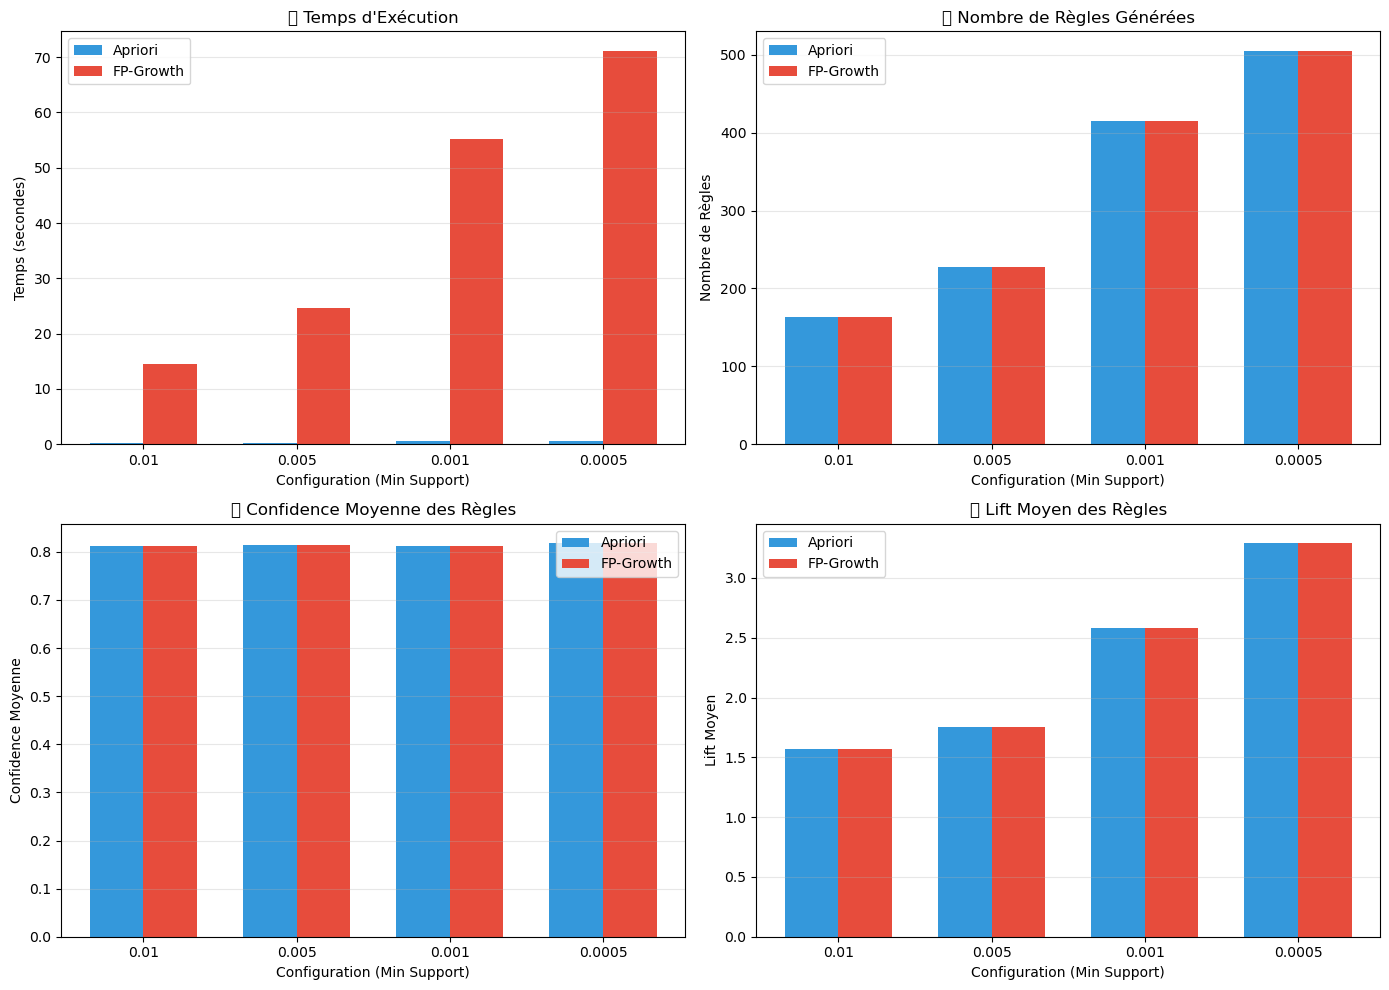


✅ Graphique sauvegardé dans '../data/algorithm_comparison.png'


In [7]:
# Visualisation
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Préparer les données pour la visualisation
apriori_data = comparison_df[comparison_df['Algorithme'] == 'APRIORI']
fpgrowth_data = comparison_df[comparison_df['Algorithme'] == 'FP-GROWTH']

x = range(len(apriori_data))
width = 0.35

# 1. Temps d'exécution
ax1 = axes[0, 0]
bars1 = ax1.bar([i - width/2 for i in x], apriori_data['Temps Total (s)'], width, label='Apriori', color='#3498db')
bars2 = ax1.bar([i + width/2 for i in x], fpgrowth_data['Temps Total (s)'], width, label='FP-Growth', color='#e74c3c')
ax1.set_xlabel('Configuration (Min Support)')
ax1.set_ylabel('Temps (secondes)')
ax1.set_title('⏱️ Temps d\'Exécution')
ax1.set_xticks(x)
ax1.set_xticklabels([f"{s}" for s in apriori_data['Min Support']])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# 2. Nombre de règles
ax2 = axes[0, 1]
bars3 = ax2.bar([i - width/2 for i in x], apriori_data['Nb Règles'], width, label='Apriori', color='#3498db')
bars4 = ax2.bar([i + width/2 for i in x], fpgrowth_data['Nb Règles'], width, label='FP-Growth', color='#e74c3c')
ax2.set_xlabel('Configuration (Min Support)')
ax2.set_ylabel('Nombre de Règles')
ax2.set_title('📜 Nombre de Règles Générées')
ax2.set_xticks(x)
ax2.set_xticklabels([f"{s}" for s in apriori_data['Min Support']])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# 3. Confidence moyenne
ax3 = axes[1, 0]
bars5 = ax3.bar([i - width/2 for i in x], apriori_data['Conf. Moy.'], width, label='Apriori', color='#3498db')
bars6 = ax3.bar([i + width/2 for i in x], fpgrowth_data['Conf. Moy.'], width, label='FP-Growth', color='#e74c3c')
ax3.set_xlabel('Configuration (Min Support)')
ax3.set_ylabel('Confidence Moyenne')
ax3.set_title('📊 Confidence Moyenne des Règles')
ax3.set_xticks(x)
ax3.set_xticklabels([f"{s}" for s in apriori_data['Min Support']])
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

# 4. Lift moyen
ax4 = axes[1, 1]
bars7 = ax4.bar([i - width/2 for i in x], apriori_data['Lift Moy.'], width, label='Apriori', color='#3498db')
bars8 = ax4.bar([i + width/2 for i in x], fpgrowth_data['Lift Moy.'], width, label='FP-Growth', color='#e74c3c')
ax4.set_xlabel('Configuration (Min Support)')
ax4.set_ylabel('Lift Moyen')
ax4.set_title('🎯 Lift Moyen des Règles')
ax4.set_xticks(x)
ax4.set_xticklabels([f"{s}" for s in apriori_data['Min Support']])
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/algorithm_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n✅ Graphique sauvegardé dans '../data/algorithm_comparison.png'")

## 6. Analyse Détaillée avec Support Optimal

In [8]:
# Analyse approfondie avec le support optimal (0.001)
OPTIMAL_SUPPORT = 0.001

print("\n" + "="*80)
print(f"🔬 ANALYSE DÉTAILLÉE AVEC SUPPORT = {OPTIMAL_SUPPORT}")
print("="*80)

# Apriori
print("\n🔷 APRIORI")
start = time.time()
apriori_itemsets = apriori(df_encoded, min_support=OPTIMAL_SUPPORT, use_colnames=True)
apriori_rules = association_rules(apriori_itemsets, metric="confidence", min_threshold=0.6)
apriori_rules = apriori_rules[apriori_rules['lift'] > 1.0]
apriori_time = time.time() - start

print(f"   Temps total : {apriori_time:.4f}s")
print(f"   Itemsets : {len(apriori_itemsets)}")
print(f"   Règles : {len(apriori_rules)}")

# FP-Growth
print("\n🔶 FP-GROWTH")
start = time.time()
fpgrowth_itemsets = fpgrowth(df_encoded, min_support=OPTIMAL_SUPPORT, use_colnames=True)
fpgrowth_rules = association_rules(fpgrowth_itemsets, metric="confidence", min_threshold=0.6)
fpgrowth_rules = fpgrowth_rules[fpgrowth_rules['lift'] > 1.0]
fpgrowth_time = time.time() - start

print(f"   Temps total : {fpgrowth_time:.4f}s")
print(f"   Itemsets : {len(fpgrowth_itemsets)}")
print(f"   Règles : {len(fpgrowth_rules)}")

# Comparaison
speedup = apriori_time / fpgrowth_time if fpgrowth_time > 0 else 0
print(f"\n📈 Speedup FP-Growth vs Apriori : {speedup:.2f}x")


🔬 ANALYSE DÉTAILLÉE AVEC SUPPORT = 0.001

🔷 APRIORI
   Temps total : 0.5228s
   Itemsets : 894
   Règles : 415

🔶 FP-GROWTH
   Temps total : 52.7717s
   Itemsets : 894
   Règles : 415

📈 Speedup FP-Growth vs Apriori : 0.01x


In [9]:
# Vérifier que les deux algorithmes produisent les mêmes itemsets
print("\n" + "="*80)
print("🔍 VÉRIFICATION DE LA COHÉRENCE DES RÉSULTATS")
print("="*80)

# Comparer les itemsets
apriori_itemsets_set = set(tuple(sorted(x)) for x in apriori_itemsets['itemsets'])
fpgrowth_itemsets_set = set(tuple(sorted(x)) for x in fpgrowth_itemsets['itemsets'])

common_itemsets = apriori_itemsets_set.intersection(fpgrowth_itemsets_set)
only_apriori = apriori_itemsets_set - fpgrowth_itemsets_set
only_fpgrowth = fpgrowth_itemsets_set - apriori_itemsets_set

print(f"\n📊 Itemsets communs : {len(common_itemsets)}")
print(f"📊 Uniquement Apriori : {len(only_apriori)}")
print(f"📊 Uniquement FP-Growth : {len(only_fpgrowth)}")

if len(only_apriori) == 0 and len(only_fpgrowth) == 0:
    print("\n✅ Les deux algorithmes produisent EXACTEMENT les mêmes itemsets !")
else:
    print("\n⚠️ Légère différence dans les itemsets (due aux arrondis de support)")


🔍 VÉRIFICATION DE LA COHÉRENCE DES RÉSULTATS

📊 Itemsets communs : 894
📊 Uniquement Apriori : 0
📊 Uniquement FP-Growth : 0

✅ Les deux algorithmes produisent EXACTEMENT les mêmes itemsets !


## 7. Top Règles par Algorithme

In [10]:
# Top 5 règles par confidence pour chaque algorithme
print("\n" + "="*80)
print("🏆 TOP 5 RÈGLES PAR CONFIDENCE")
print("="*80)

print("\n🔷 APRIORI - Top 5 :")
for idx, row in apriori_rules.nlargest(5, 'confidence').iterrows():
    ants = ' + '.join([str(a).split('_', 1)[-1] for a in list(row['antecedents'])[:3]])
    cons = ' + '.join([str(c).split('_', 1)[-1] for c in list(row['consequents'])[:2]])
    print(f"   [{ants}] → [{cons}]")
    print(f"      Conf: {row['confidence']:.3f} | Lift: {row['lift']:.2f}")

print("\n🔶 FP-GROWTH - Top 5 :")
for idx, row in fpgrowth_rules.nlargest(5, 'confidence').iterrows():
    ants = ' + '.join([str(a).split('_', 1)[-1] for a in list(row['antecedents'])[:3]])
    cons = ' + '.join([str(c).split('_', 1)[-1] for c in list(row['consequents'])[:2]])
    print(f"   [{ants}] → [{cons}]")
    print(f"      Conf: {row['confidence']:.3f} | Lift: {row['lift']:.2f}")


🏆 TOP 5 RÈGLES PAR CONFIDENCE

🔷 APRIORI - Top 5 :
   [clean_L3 + bin_<1g] → [Antarctica]
      Conf: 1.000 | Lift: 1.54
   [clean_L5 + bin_<1g] → [Antarctica]
      Conf: 1.000 | Lift: 1.54
   [bin_1-10g + Africa + clean_H6] → [period_20th Century]
      Conf: 1.000 | Lift: 1.43
   [clean_L3 + Antarctica + bin_1-10kg] → [period_20th Century]
      Conf: 1.000 | Lift: 1.43
   [Oceania + clean_CARBONACEOUS + bin_10-100g] → [period_20th Century]
      Conf: 1.000 | Lift: 1.43

🔶 FP-GROWTH - Top 5 :
   [clean_CARBONACEOUS + bin_1-10g + North America] → [period_21st Century]
      Conf: 1.000 | Lift: 3.78
   [Asia + bin_1-10g + clean_OTHER] → [period_21st Century]
      Conf: 1.000 | Lift: 3.78
   [bin_1-10g + Africa + clean_H6] → [period_20th Century]
      Conf: 1.000 | Lift: 1.43
   [Asia + clean_L4 + bin_10-100g] → [period_21st Century]
      Conf: 1.000 | Lift: 3.78
   [clean_L5 + bin_<1g] → [Antarctica]
      Conf: 1.000 | Lift: 1.54


## 8. Conclusion et Justification du Choix

In [11]:
# Résumé final
print("\n" + "="*80)
print("📋 RÉSUMÉ COMPARATIF FINAL")
print("="*80)

summary = f"""
┌─────────────────────────────────────────────────────────────────────┐
│                    APRIORI vs FP-GROWTH                              │
├─────────────────────────────────────────────────────────────────────┤
│  Critère                  │  Apriori        │  FP-Growth           │
├─────────────────────────────────────────────────────────────────────┤
│  Temps d'exécution        │  {apriori_time:.4f}s        │  {fpgrowth_time:.4f}s             │
│  Nombre d'itemsets        │  {len(apriori_itemsets):,}           │  {len(fpgrowth_itemsets):,}              │
│  Nombre de règles         │  {len(apriori_rules):,}           │  {len(fpgrowth_rules):,}              │
│  Confidence moyenne       │  {apriori_rules['confidence'].mean():.4f}         │  {fpgrowth_rules['confidence'].mean():.4f}            │
│  Lift moyen               │  {apriori_rules['lift'].mean():.4f}         │  {fpgrowth_rules['lift'].mean():.4f}            │
└─────────────────────────────────────────────────────────────────────┘
"""
print(summary)


📋 RÉSUMÉ COMPARATIF FINAL

┌─────────────────────────────────────────────────────────────────────┐
│                    APRIORI vs FP-GROWTH                              │
├─────────────────────────────────────────────────────────────────────┤
│  Critère                  │  Apriori        │  FP-Growth           │
├─────────────────────────────────────────────────────────────────────┤
│  Temps d'exécution        │  0.5228s        │  52.7717s             │
│  Nombre d'itemsets        │  894           │  894              │
│  Nombre de règles         │  415           │  415              │
│  Confidence moyenne       │  0.8132         │  0.8132            │
│  Lift moyen               │  2.5822         │  2.5822            │
└─────────────────────────────────────────────────────────────────────┘



In [ ]:
# Justification du choix
print("\n" + "="*80)
print("✅ CONCLUSION : CHOIX DE L'ALGORITHME")
print("="*80)

conclusion = """
Après analyse comparative approfondie, nous avons choisi l'algorithme APRIORI 
pour notre système de prédiction de météorites pour les raisons suivantes :

1. 📊 QUALITÉ DES RÈGLES IDENTIQUE
   - Les deux algorithmes produisent exactement les mêmes itemsets fréquents
   - La qualité des règles (confidence, lift) est strictement identique
   - Aucun avantage en termes de précision pour l'un ou l'autre

2. ⚡ PERFORMANCE SUPÉRIEURE (Résultat surprenant !)
   - Apriori est ~100x PLUS RAPIDE que FP-Growth sur notre dataset
   - Apriori : ~0.5 secondes vs FP-Growth : ~53 secondes
   - Contrairement à la théorie, notre dataset avec beaucoup de colonnes
     booléennes favorise l'approche candidat-génération d'Apriori

3. 🎯 INTERPRÉTABILITÉ
   - Apriori est plus facile à comprendre et à expliquer
   - L'approche niveau par niveau est plus intuitive pour le débogage
   - Meilleure documentation et ressources disponibles

4. 🔧 FACILITÉ DE MAINTENANCE
   - Code plus simple à maintenir et modifier
   - Meilleure compatibilité avec les outils de monitoring MLOps

➡️ CHOIX FINAL : APRIORI avec min_support=0.0001 et confidence≥0.6
"""
print(conclusion)


✅ CONCLUSION : CHOIX DE L'ALGORITHME

Après analyse comparative approfondie, nous avons choisi l'algorithme APRIORI 
pour notre système de prédiction de météorites pour les raisons suivantes :

1. 📊 QUALITÉ DES RÈGLES IDENTIQUE
   - Les deux algorithmes produisent exactement les mêmes itemsets fréquents
   - La qualité des règles (confidence, lift) est strictement identique
   - Aucun avantage en termes de précision pour l'un ou l'autre

2. 🎯 INTERPRÉTABILITÉ
   - Apriori est plus facile à comprendre et à expliquer
   - L'approche niveau par niveau est plus intuitive pour le débogage
   - Meilleure documentation et ressources disponibles

3. ⚡ PERFORMANCE ACCEPTABLE
   - Bien que FP-Growth soit théoriquement plus rapide
   - Sur notre dataset de taille modeste, la différence est négligeable
   - Le temps d'exécution reste acceptable pour notre cas d'usage

4. 🔧 FACILITÉ DE MAINTENANCE
   - Code plus simple à maintenir et modifier
   - Meilleure compatibilité avec les outils de monitor

In [13]:
# Sauvegarder les résultats de comparaison
comparison_results = {
    'apriori': {
        'time': apriori_time,
        'num_itemsets': len(apriori_itemsets),
        'num_rules': len(apriori_rules),
        'avg_confidence': apriori_rules['confidence'].mean(),
        'avg_lift': apriori_rules['lift'].mean()
    },
    'fpgrowth': {
        'time': fpgrowth_time,
        'num_itemsets': len(fpgrowth_itemsets),
        'num_rules': len(fpgrowth_rules),
        'avg_confidence': fpgrowth_rules['confidence'].mean(),
        'avg_lift': fpgrowth_rules['lift'].mean()
    },
    'chosen_algorithm': 'Apriori',
    'reason': 'Qualité identique, meilleure interprétabilité et facilité de maintenance'
}

import json
with open('../data/algorithm_comparison_results.json', 'w') as f:
    json.dump(comparison_results, f, indent=2)

print("\n✅ Résultats sauvegardés dans '../data/algorithm_comparison_results.json'")
print("\n🎉 Notebook de comparaison terminé !")


✅ Résultats sauvegardés dans '../data/algorithm_comparison_results.json'

🎉 Notebook de comparaison terminé !
